# Data

In [4]:
from huggingface_hub import hf_hub_download, login

In [5]:
login()

In [10]:
hf_hub_download(repo_id='Jungle15/GDP-HMM_Challenge', filename='train_HaN.zip', repo_type="dataset", local_dir='.')

train_HaN.zip:   0%|          | 0.00/17.6G [00:00<?, ?B/s]

'train_HaN.zip'

In [11]:
hf_hub_download(repo_id='Jungle15/GDP-HMM_Challenge', filename='train_Lung.zip', repo_type="dataset", local_dir='.')

train_Lung.zip:   0%|          | 0.00/21.4G [00:00<?, ?B/s]

'train_Lung.zip'

# Train

In [1]:
from pathlib import Path
import sys
import torch
import torch.nn as nn
import torch.optim as optim
from nnunet_mednext import create_mednext_v1
import yaml
from pprint import pprint

from tqdm import tqdm
import numpy as np

In [2]:
code_dir = Path('/workspace/gdp-hmm-model')
sys.path.append(str(code_dir)) # Need to be string
sys.path.append(str(code_dir/'mednext'))

In [3]:
%load_ext autoreload
%autoreload 2

import data_loader



In [4]:
cfig = yaml.load(open(code_dir / 'config_files/config.yaml'), Loader=yaml.FullLoader)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
# loaders = data_loader.GetLoader(cfig = cfig['loader_params'])
# train_loader =loaders.train_dataloader()
# val_loader = loaders.val_dataloader()

In [6]:
model = create_mednext_v1( num_input_channels = cfig['model_params']['num_input_channels'],
  num_classes = cfig['model_params']['out_channels'],
  model_id = cfig['model_params']['model_id'],          # S, B, M and L are valid model ids
  kernel_size = cfig['model_params']['kernel_size'],   # 3x3x3 and 5x5x5 were tested in publication
  deep_supervision = cfig['model_params']['deep_supervision']
).to(device)

In [7]:
# ds_cfig = {
#   'train_bs': 1,
#   'val_bs': 1,
#   'num_workers': 0,
#   'csv_root': code_dir/'meta_files/meta_data.csv',
#   'scale_dose_dict': code_dir/'meta_files/PTV_DICT.json',
#   'pat_obj_dict': code_dir/'meta_files/Pat_Obj_DICT.json',
#   'down_HU': -1000,
#   'up_HU': 1000,
#   'denom_norm_HU': 500,
#   'in_size': (96, 128, 144),
#   'out_size': (96, 128, 144),
#   'norm_oar': True,
#   'CatStructures': False,
#   'dose_div_factor': 10
# }

# from data_loader import MyDataset
# dataset = MyDataset(ds_cfig, 'train')


# Dataset and DataLoader

In [8]:
from pathlib import Path
import numpy as np
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

In [8]:
# Using ids
class ChallengeData(Dataset):
    def __init__(self, data_dir, ids):
        super().__init__()
        self.data_dir = Path(data_dir)
        self.ids = ids
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        npz_path = self.data_dir / f'{self.ids[idx]}.npz'

        data_dict = dict(np.load(npz_path))

        # Unsqueeze the 1st dim: x -> (8, 96, 128, 144)
        x = torch.from_numpy(data_dict['data'])[0].to(self.device)
        y = torch.from_numpy(data_dict['label'])[0].to(self.device)

        # Mask, derived from x
        body_mask = x[3:4,...].bool()
        outbody_mask = ~body_mask
        ptv_mask = x[1:2, ...].bool()
        near_mask = torch.logical_and(~ptv_mask, body_mask)
        
        return x, y, body_mask, outbody_mask, ptv_mask, near_mask


In [22]:
# Fixed length, random sampled
# extra param: size -> size of the dataset

class ChallengeData(Dataset):
    def __init__(self, data_dir, ids, size=None):
        super().__init__()
        self.data_dir = Path(data_dir)
        self.ids = ids
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'

        self.size = size if size is not None else len(ids)
        self._sample()

    def __len__(self):
        return self.size

    def _sample(self):
        if self.size < len(self.ids):
            self.current_ids = np.random.choice(self.ids, self.size, replace=False).tolist()
            print('Dataset resampled')
        else:
            self.current_ids = self.ids.copy()
            print('Dataset all samples used')

    def __getitem__(self, idx):
        npz_path = self.data_dir / f'{self.current_ids[idx]}.npz'

        data_dict = dict(np.load(npz_path))

        # Unsqueeze the 1st dim: x -> (8, 96, 128, 144)
        x = torch.from_numpy(data_dict['data'])[0].to(self.device)
        y = torch.from_numpy(data_dict['label'])[0].to(self.device)

        # Mask, derived from x
        body_mask = x[3:4,...].bool()
        outbody_mask = ~body_mask
        ptv_mask = x[1:2, ...].bool()
        near_mask = torch.logical_and(~ptv_mask, body_mask)

        if idx==self.size-1: self._sample()
            
        return x, y, body_mask, outbody_mask, ptv_mask, near_mask

In [28]:
np.random.choice([1,2,3], 2, replace=False)

array([2, 3])

In [10]:
from sklearn.model_selection import train_test_split

others, test_ids = train_test_split(range(2728), test_size=0.3, random_state=1234)
train_ids, val_ids = train_test_split(others, test_size=0.3, random_state=1234)

In [23]:
batch_size = 4

data_tr = ChallengeData('/workspace/data/train_data_dict', train_ids, size=100)
loader_tr = DataLoader(data_tr, batch_size=batch_size, shuffle=False)

data_vl = ChallengeData('/workspace/data/train_data_dict', val_ids, size=20)
loader_vl = DataLoader(data_vl, batch_size=batch_size, shuffle=False)

data_ts = ChallengeData('/workspace/data/train_data_dict', test_ids)
loader_ts = DataLoader(data_ts, batch_size=batch_size, shuffle=False)


Dataset resampled
Dataset resampled
Dataset all samples used


In [11]:
len(data_tr), len(data_vl), len(data_ts)

(100, 20, 819)

In [12]:
optimizer = optim.Adam(model.parameters(), lr=cfig['lr'])
criterion = nn.L1Loss()
epochs = 10

In [13]:
def cal_error(pred, gt, body):
    isodose_5Gy_mask = ((gt > 5) | (pred > 5)) & (body > 0)
    isodose_ref_5Gy_mask = (gt > 5) & (body > 0)
    diff = gt - pred
    error = torch.sum(torch.abs(diff)[isodose_5Gy_mask > 0]) / torch.sum(isodose_ref_5Gy_mask)
    return error

def custom_loss(outputs, y, body_mask, outbody_mask, ptv_mask, near_mask, _id):
    if _id == 1:
        loss = criterion(outputs, y)
    if _id == 2:
        loss = criterion(outputs[body_mask], y[body_mask])
    if _id == 3:
        loss = criterion(outputs[body_mask], y[body_mask]) + 5 * criterion(outputs[near_mask], y[near_mask])
    if _id == 4:
        loss = cal_error(outputs, y, body_mask) + criterion(outputs, y) + torch.max(outputs[outbody_mask])

    return loss

In [33]:
loss_id = 2

In [35]:
for epoch in range(epochs):
    model.train()
    
    pbar = tqdm(loader_tr, f'Epoch {epoch}')
    
    train_loss = []
    for x, y, body_mask, outbody_mask, ptv_mask, near_mask in pbar:
        
      # Forward pass
      outputs = model(x.to(device))

      loss = custom_loss(outputs, y, body_mask, outbody_mask, ptv_mask, near_mask, _id=loss_id)
    
      # Backward pass and optimization
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
    
      train_loss.append(loss.detach().cpu().item())
      pbar.set_postfix_str(f'Loss: {loss.item():.3f}')
    
    val_loss = []
    model.eval()
    for x, y, body_mask, outbody_mask, ptv_mask, near_mask in loader_vl:
        with torch.no_grad():
            outputs = model(x.to(device))
            loss = custom_loss(outputs, y, body_mask, outbody_mask, ptv_mask, near_mask, _id=loss_id)
            val_loss.append(loss.detach().cpu().item())
    
    print(f'Train loss: {np.mean(train_loss):.3f}  Val loss: {np.mean(val_loss):.3f}')


Epoch 0:   0%|          | 0/25 [00:00<?, ?it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 864.00 MiB. GPU 0 has a total capacty of 79.14 GiB of which 446.75 MiB is free. Process 2754920 has 78.69 GiB memory in use. Of the allocated memory 75.88 GiB is allocated by PyTorch, and 2.30 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF

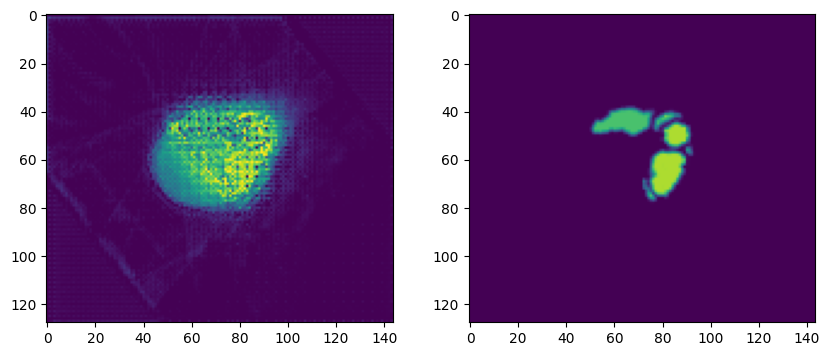

In [18]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(outputs[0,0,35].detach().cpu(), vmin=0, vmax=8)
ax[1].imshow(x.cpu()[0,0,35], vmin=0, vmax=8)

In [38]:
ref_dose = data_dict['label'].cpu().numpy()
prediction = outputs.detach().cpu().numpy()
body = body_mask.cpu().numpy()

isodose_5Gy_mask = ((ref_dose > 5) | (prediction > 5)) & (body > 0) # the mask include the body AND the region where the dose/prediction is higher than 5Gy

isodose_ref_5Gy_mask = (ref_dose > 5) & (body > 0) # the mask include the body AND the region where the ref is higher than 5Gy

diff = ref_dose - prediction

error = np.sum(np.abs(diff)[isodose_5Gy_mask > 0]) / np.sum(isodose_ref_5Gy_mask)

In [50]:
cal_error(outputs.detach().cpu(), data_dict['label'], body_mask.cpu().numpy())

tensor(1.3662)

In [39]:
error

1.3662197851783693

# Test

In [25]:
ts_loss = []
model.eval()
for x, y, body_mask, outbody_mask, ptv_mask, near_mask in loader_ts:
    with torch.no_grad():
        outputs = model(x.to(device))
        # loss = criterion(outputs, y)
        
        loss = cal_error(outputs, y, body_mask)
        ts_loss.append(loss.detach().cpu().item())

print(f'Test loss: {np.mean(val_loss):.3f}')

Dataset all samples used
Test loss: 0.518


In [27]:
torch.save(model.state_dict(), 'weights/epoch_20_loss_1.pt')

In [29]:
model2 = create_mednext_v1( num_input_channels = cfig['model_params']['num_input_channels'],
  num_classes = cfig['model_params']['out_channels'],
  model_id = cfig['model_params']['model_id'],          # S, B, M and L are valid model ids
  kernel_size = cfig['model_params']['kernel_size'],   # 3x3x3 and 5x5x5 were tested in publication
  deep_supervision = cfig['model_params']['deep_supervision']
).to(device)

In [30]:
model2.load_state_dict(torch.load('weights/epoch_20_loss_1.pt'))

<All keys matched successfully>

In [31]:
outputs = model2(x)

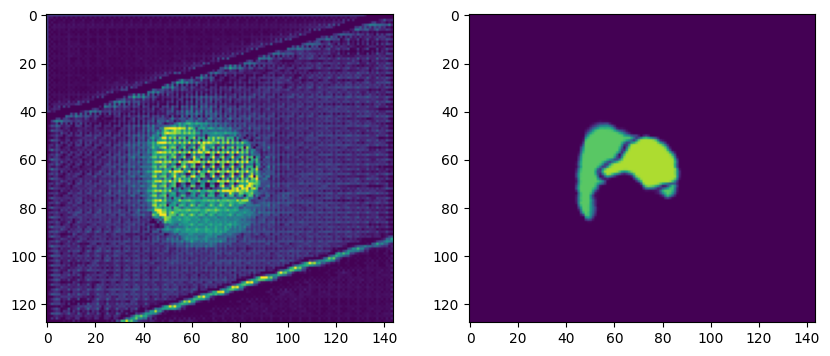

In [32]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(outputs[0,0,35].detach().cpu(), vmin=0, vmax=8)
ax[1].imshow(x.cpu()[0,0,35], vmin=0, vmax=8)